# Proyecto Random Forest (Diabetes)

En este notebook voy a hacer el proyecto paso a paso.  
Primero reviso los datos, hago una limpieza básica y luego entreno un modelo de Random Forest para predecir si una persona tiene diabetes.

## 1. Importar librerías

Importo todo al principio para tenerlo ordenado.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from pickle import dump

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

## 2. Cargar los datos

Cargo el dataset desde la URL.

In [2]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
data = pd.read_csv(url)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Revisión rápida

Miro tamaño, duplicados y nulos.

In [3]:
data.shape

(768, 9)

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 4. Limpieza

Elimino duplicados si hay.

In [6]:
data = data.drop_duplicates().reset_index(drop=True)
data.shape

(768, 9)

## 5. EDA sencillo

Miro la variable objetivo y algunas distribuciones.

In [7]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

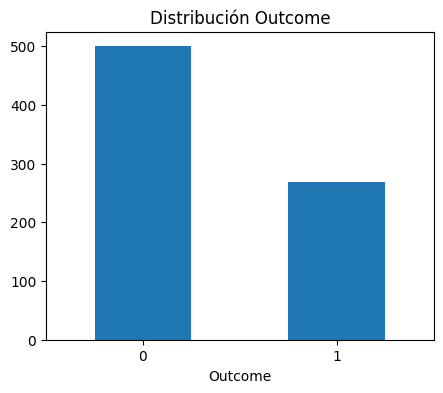

In [8]:
plt.figure(figsize=(5,4))
data['Outcome'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución Outcome')
plt.xticks(rotation=0)
plt.show()

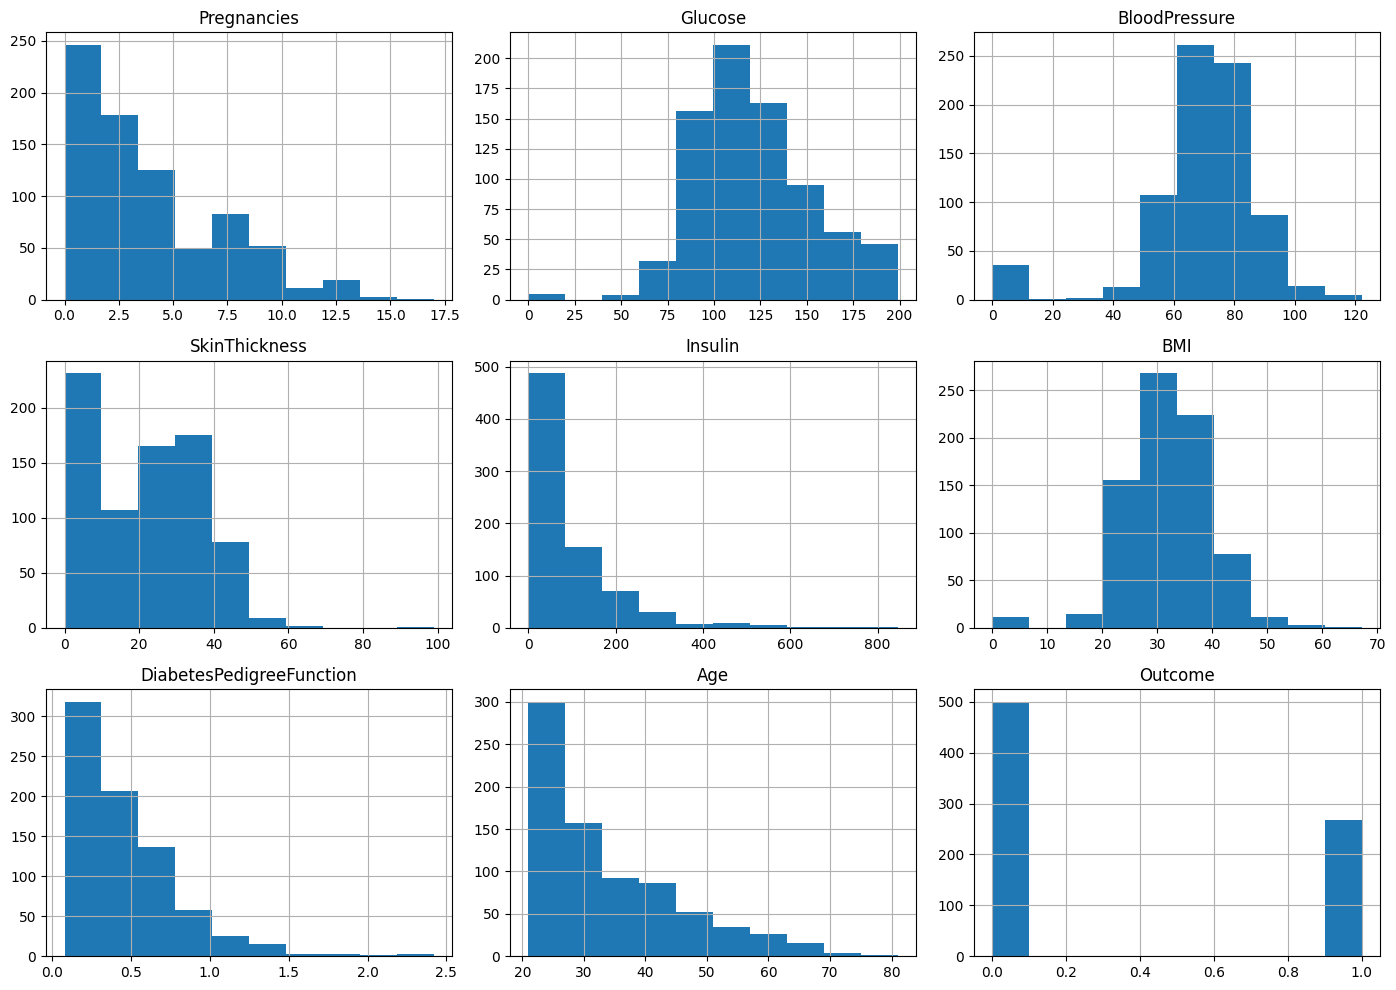

In [9]:
data.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

También hago un mapa de correlación rápido para ver relaciones.

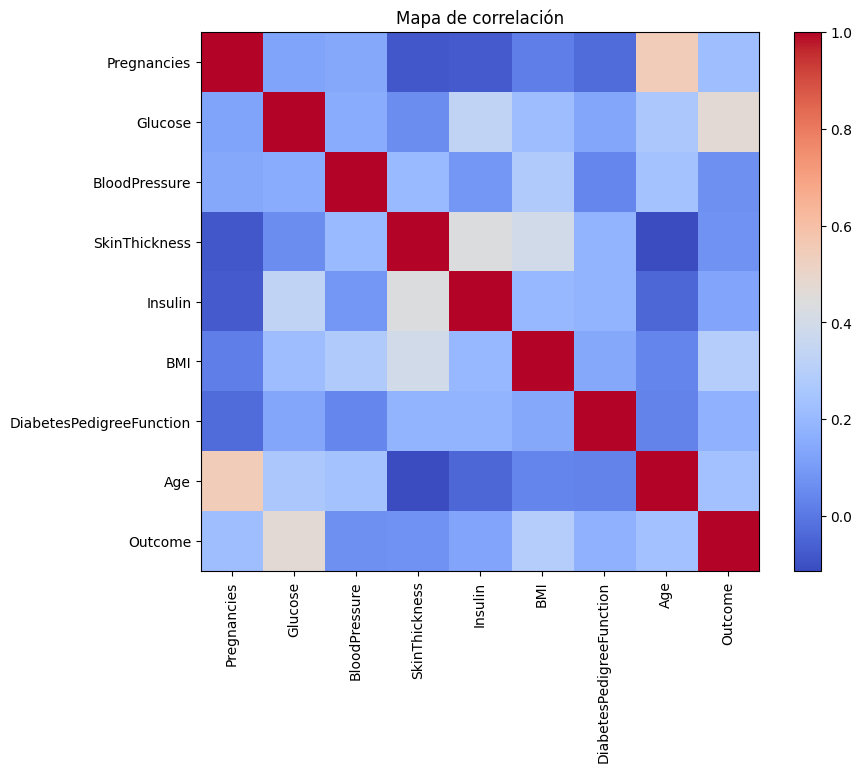

In [10]:
corr = data.corr()

plt.figure(figsize=(9,7))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Mapa de correlación')
plt.show()

## 6. Preparar datos

Separo X e y y hago train/test con stratify.

In [11]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((614, 8), (154, 8))

## 7. Selección de variables

Uso SelectKBest para quedarme con algunas variables.

In [12]:
selector = SelectKBest(k=7)
selector.fit(X_train, y_train)

selected_cols = X_train.columns[selector.get_support()]
selected_cols

Index(['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age'],
      dtype='str')

In [13]:
X_train_sel = pd.DataFrame(selector.transform(X_train), columns=selected_cols)
X_test_sel = pd.DataFrame(selector.transform(X_test), columns=selected_cols)

X_train_sel.head()

,Pregnancies,Glucose,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1.0,90.0,12.0,43.0,27.2,0.580,24.0
1,5.0,126.0,27.0,22.0,29.6,0.439,40.0
2,2.0,105.0,40.0,94.0,34.9,0.225,25.0
3,1.0,146.0,0.0,0.0,29.7,0.564,29.0
4,0.0,95.0,39.0,105.0,44.6,0.366,22.0


## 8. Modelo Random Forest

Entreno un modelo básico.

In [14]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_sel, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
y_pred = model.predict(X_test_sel)
y_pred[:10]

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1])

In [16]:
accuracy_score(y_test, y_pred)

0.7597402597402597

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



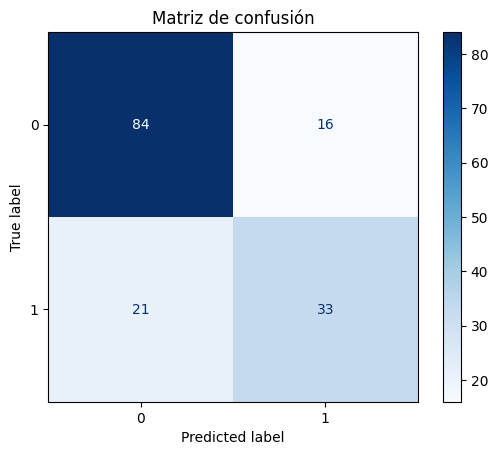

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

## 9. Optimización sencilla

Pruebo algunos parámetros para mejorar el modelo.

In [19]:
params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    scoring='accuracy',
    cv=5
)

grid.fit(X_train_sel, y_train)

grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 100}

In [20]:
grid.best_score_

np.float64(0.7769292283086765)

In [21]:
best_model = grid.best_estimator_
best_model.fit(X_train_sel, y_train)

y_pred_opt = best_model.predict(X_test_sel)

print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))
print("Accuracy:", accuracy_score(y_test, y_pred_opt))

[[83 17]
 [25 29]]
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       100
           1       0.63      0.54      0.58        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154

Accuracy: 0.7272727272727273


## 10. Guardar modelo

Guardo el modelo final.

In [22]:
os.makedirs("models", exist_ok=True)
dump(best_model, open("models/random_forest_diabetes.sav", "wb"))

## Conclusión

He entrenado un modelo de Random Forest después de hacer una limpieza básica y selección de variables.  
El modelo mejora respecto a un árbol simple y es más robusto, aunque todavía se podría ajustar más.